# Classificação — Análise Exploratória de Dados (EDA)

**Dataset:** acidentes em rodovias federais registrados pela PRF em 2024. Fonte: [Portal Brasileiro de Dados Abertos](https://dados.gov.br/dataset/acidentes-rodovias-federais).

**Alvo:** `com_vitima_fatal` (binário) — indica se o acidente teve pelo menos uma vítima fatal. É uma classe minoritária (~7% dos casos), o que torna este um problema de classificação desbalanceada.

**Escopo deste notebook:** apenas exploração e entendimento dos dados — qualidade, distribuições, correlações e o desbalanceamento do alvo. Nenhuma transformação, split ou modelagem acontece aqui.

**Próximas etapas** (em notebooks separados, na pasta `notebooks/`):
1. `02_Preprocessamento_Baseline.ipynb` — split treino/teste, pipeline de pré-processamento e baseline
2. `03_Comparacao_Modelos.ipynb` — comparação de modelos com validação cruzada
3. `04_Otimizacao_Optuna.ipynb` — otimização bayesiana de hiperparâmetros com Optuna

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar os dados

In [2]:
# Dataset: acidentes de transito em rodovias federais (PRF, 2024)
# Fonte: https://dados.gov.br/dataset/acidentes-rodovias-federais
CAMINHO_DADOS = '../data/datatran2024.csv'

df = pd.read_csv(CAMINHO_DADOS, sep=';', encoding='latin1')
print('Linhas x Colunas:', df.shape)
df.head()

Linhas x Colunas: (73156, 30)


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,571789.0,2024-01-01,segunda-feira,03:56:00,ES,101,38,CONCEICAO DA BARRA,Ultrapassagem Indevida,Colisão lateral sentido oposto,NaN,Plena Noite,Crescente,Céu Claro,Simples,Reta,Não,3,0,0,1,1,1,1,3,-18.482610,-39.923790,SPRF-ES,DEL04-ES,UOP02-DEL04-ES
1,571804.0,2024-01-01,segunda-feira,04:50:00,PI,343,185,PIRIPIRI,Manobra de mudança de faixa,Colisão frontal,Com Vítimas Fatais,Amanhecer,Decrescente,Céu Claro,Simples,Reta,Sim,2,1,0,0,1,0,0,2,-4.296033,-41.767327,SPRF-PI,DEL02-PI,UOP01-DEL02-PI
2,571806.0,2024-01-01,segunda-feira,04:30:00,BA,116,578,BREJOES,Ingestão de álcool pelo condutor,Colisão frontal,Com Vítimas Fatais,Plena Noite,Decrescente,Céu Claro,Simples,Curva,Não,3,1,0,0,1,2,0,4,-13.071583,-39.961111,SPRF-BA,DEL03-BA,UOP02-DEL03-BA
3,571818.0,2024-01-01,segunda-feira,06:30:00,SE,101,18,MALHADA DOS BOIS,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Amanhecer,Crescente,Céu Claro,Dupla,Declive;Reta,Não,2,0,0,1,0,2,1,3,-10.356019,-36.905522,SPRF-SE,DEL02-SE,UOP02-DEL02-SE
4,571838.0,2024-01-01,segunda-feira,05:00:00,MT,364,240,RONDONOPOLIS,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,3,0,0,0,2,1,0,3,-16.179141,-54.789053,SPRF-MT,DEL02-MT,UOP01-DEL02-MT


### 2.1 Binarização do alvo

A coluna original `classificacao_acidente` tem 3 classes ("Sem Vítimas", "Com Vítimas Feridas", "Com Vítimas Fatais"). Para um problema de classificação binária desbalanceada, criamos `com_vitima_fatal` (1 = houve vítima fatal, 0 = não houve).

Essa recodificação é determinística (não usa estatísticas dos dados), então pode ser feita antes do split sem causar data leakage.

In [3]:
# Classe alvo binaria: houve vitima fatal no acidente?
df['com_vitima_fatal'] = (df['classificacao_acidente'] == 'Com Vítimas Fatais').astype(int)

print(df['com_vitima_fatal'].value_counts())
print()
print((df['com_vitima_fatal'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

com_vitima_fatal
0    67934
1     5222
Name: count, dtype: int64

com_vitima_fatal
0    92.86%
1     7.14%
Name: proportion, dtype: object


## 3. Visão geral e qualidade dos dados

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73156 entries, 0 to 73155
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      73156 non-null  float64
 1   data_inversa            73156 non-null  object 
 2   dia_semana              73156 non-null  object 
 3   horario                 73156 non-null  object 
 4   uf                      73156 non-null  object 
 5   br                      73156 non-null  int64  
 6   km                      73156 non-null  object 
 7   municipio               73156 non-null  object 
 8   causa_acidente          73156 non-null  object 
 9   tipo_acidente           73156 non-null  object 
 10  classificacao_acidente  73155 non-null  object 
 11  fase_dia                73156 non-null  object 
 12  sentido_via             73156 non-null  object 
 13  condicao_metereologica  73156 non-null  object 
 14  tipo_pista              73156 non-null

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,73156.0,NaN,NaN,NaN,613003.77034,23344.408649,571772.0,593042.75,613246.5,633190.25,661607.0
data_inversa,73156,366,2024-12-21,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dia_semana,73156,7,domingo,11741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
horario,73156,1415,19:00:00,1117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
uf,73156,27,MG,9296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
br,73156.0,NaN,NaN,NaN,209.575004,128.818508,0.0,101.0,158.0,324.0,495.0
km,73156,7683,1,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,73156,1833,BRASILIA,1056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causa_acidente,73156,69,Reação tardia ou ineficiente do condutor,10920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_acidente,73156,17,Colisão traseira,13960,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Valores nulos por coluna
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]

uop                       112
delegacia                  36
regional                    3
classificacao_acidente      1
dtype: int64

In [7]:
# Linhas duplicadas
print('Duplicadas:', df.duplicated().sum())

Duplicadas: 0


**Comentário:** o dataset tem 31 colunas e qualidade boa — nulos concentrados em apenas 4 colunas (`uop`, `delegacia`, `regional`, `classificacao_acidente`), todas com menos de 0,2% de linhas afetadas, e nenhuma linha duplicada. Não há necessidade de estratégias agressivas de imputação.

## 4. Distribuições

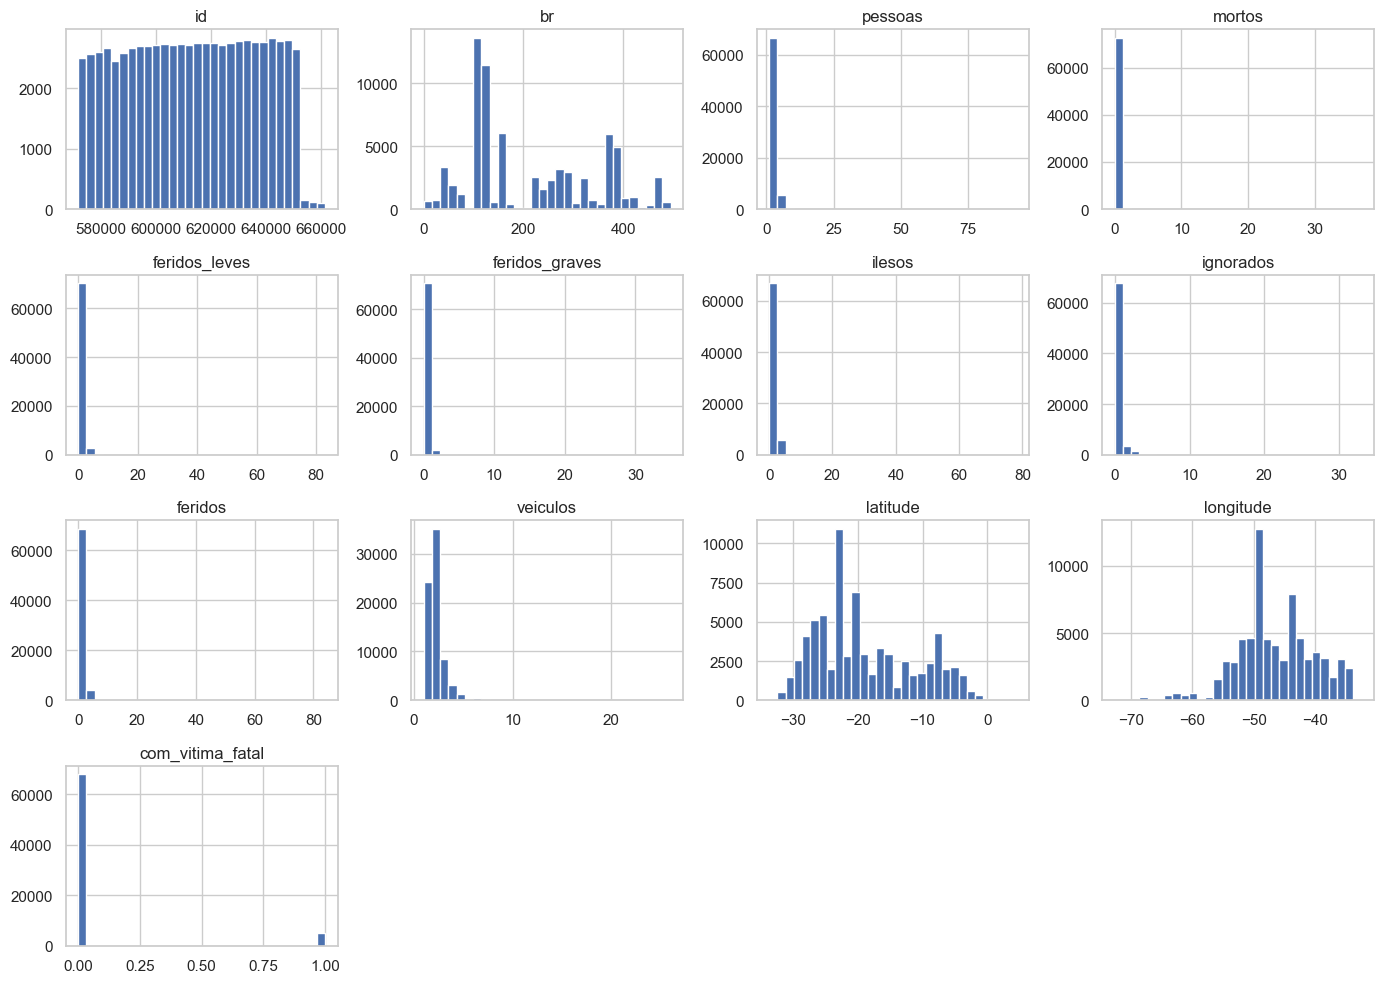

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout(); plt.show()

**Comentário:** `pessoas` (média 2,6, máximo 93) e `veiculos` (média 2,0, máximo 26) são bem assimétricas à direita — a maioria dos acidentes envolve poucas pessoas/veículos, mas há uma cauda longa de engavetamentos e ocorrências com muitas vítimas. Essa assimetria é normal para contagens desse tipo e não impede o uso direto das variáveis, mas justifica padronizá-las (`StandardScaler`) antes de modelos sensíveis a escala, como a Regressão Logística.

## 5. Correlações

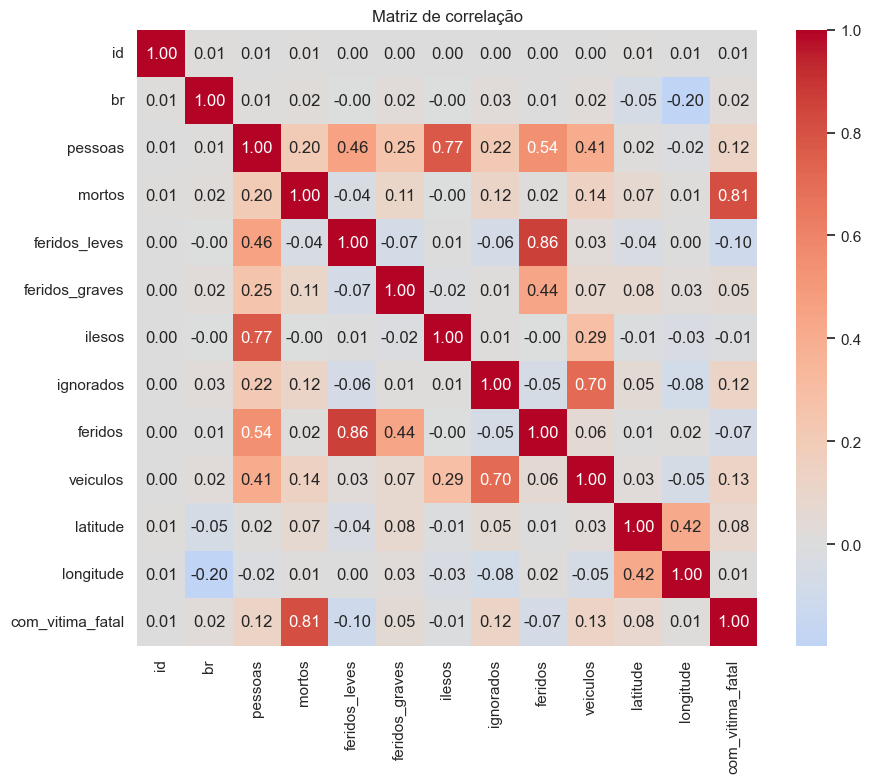

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação'); plt.show()

**Comentário:** `mortos` tem correlação de 0,81 com `com_vitima_fatal` — o que é esperado, já que a coluna original `classificacao_acidente` (da qual o alvo é derivado) é definida a partir da contagem de mortos/feridos. Por isso `mortos`, `feridos*`, `ilesos`, `ignorados` e `classificacao_acidente` são excluídas das features em `src/data.py` (`COLUNAS_VAZAMENTO`) — usá-las para prever o próprio alvo seria data leakage. As demais variáveis numéricas (`veiculos` 0,13; `pessoas` 0,12) têm correlação linear fraca com o alvo, sugerindo que o sinal preditivo real deve vir mais das variáveis categóricas (causa, condição meteorológica, tipo de pista etc.) do que de correlações lineares simples.

## 6. Variável alvo (classe)

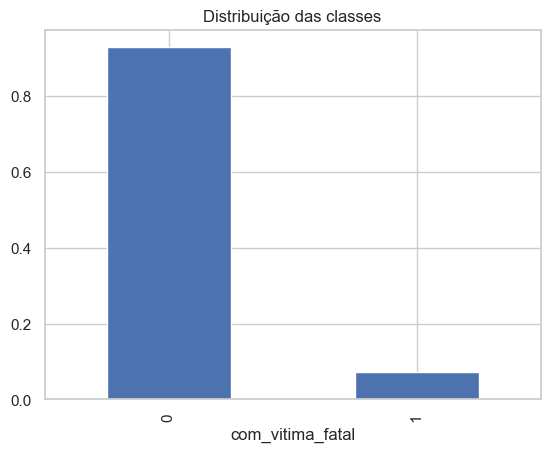

In [10]:
ALVO = 'com_vitima_fatal'  # 1 = houve vitima fatal, 0 = nao houve
df[ALVO].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribuição das classes'); plt.show()

## 7. Conclusão da EDA

- Dataset com 73.156 acidentes, poucos nulos, alvo `com_vitima_fatal` fortemente desbalanceado (~7% positivos).
- Pré-processamento, split, baseline, comparação de modelos e otimização continuam em `02_Preprocessamento_Baseline.ipynb`, `03_Comparacao_Modelos.ipynb` e `04_Otimizacao_Optuna.ipynb`.